# L8d Lab: Reproducible Cross-Validation for Ridge Regression

This notebook retains the Fall 2025 cross-validation objective but replaces the student/solution split with one deterministic workflow.

> **Learning objectives**
>
> - Partition observations into reproducible folds.
> - Fit scaling parameters on training folds only.
> - Select $\lambda$ from validation RMSE rather than training error.
> - Preserve fold-level scores so selection uncertainty remains visible.


## Setup

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week08Core` module from [`../src/Week08Core.jl`](../src/Week08Core.jl), which provides the functions called below.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


The setup cell completed, so the environment and this lab's local source are loaded. The cell below draws a seeded design matrix `X::Matrix{Float64}` of `n::Int64` observations and `p::Int64` features from `rng::MersenneTwister`, builds the response `y::Vector{Float64}` from the sparse `true_beta::Vector{Float64}`, and cross-validates over `lambdas::Vector{Float64}`. The outcome is `cv::NamedTuple`, whose fields include `mean_rmse::Vector{Float64}`, `best_lambda::Float64`, and the fold assignments `folds::Vector{Vector{Int64}}`, tabulated in `cv_table::DataFrame`.


In [2]:
rng = MersenneTwister(5800)
n, p = 120, 12
X = randn(rng, n, p)
true_beta = vcat([2.0, -1.5, 0.8], zeros(p - 3))
y = 4.0 .+ X * true_beta .+ 1.5 .* randn(rng, n)
lambdas = [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]
cv = cross_validate_ridge(X, y, lambdas; k = 6, seed = 5800)

cv_table = DataFrame(lambda = cv.lambdas, mean_rmse = cv.mean_rmse)
pretty_table(cv_table)
(selected_lambda = cv.best_lambda, fold_sizes = length.(cv.folds))


┌─────────┬───────────┐
│  lambda │ mean_rmse │
│ Float64 │   Float64 │
├─────────┼───────────┤
│     0.0 │   1.59692 │
│    0.01 │   1.59691 │
│     0.1 │   1.59682 │
│     1.0 │   1.59621 │
│    10.0 │   1.61375 │
│   100.0 │   2.07311 │
└─────────┴───────────┘


(selected_lambda = 1.0, fold_sizes = [20, 20, 20, 20, 20, 20])

In [3]:
@test sort(vcat(cv.folds...)) == collect(1:n)
@test length(unique(vcat(cv.folds...))) == n
@test cv.best_lambda in lambdas
:cross_validation_verified


:cross_validation_verified

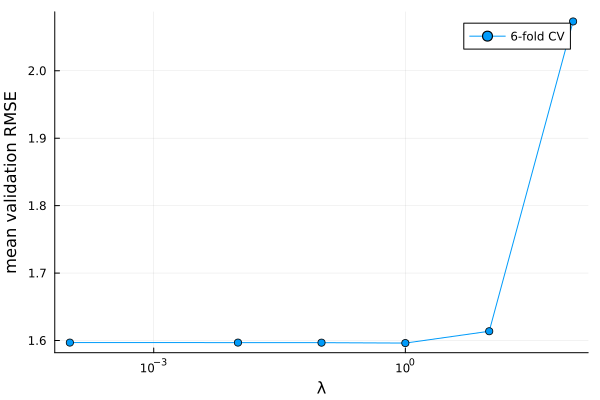

In [4]:
plot(cv.lambdas .+ 1e-4, cv.mean_rmse; xscale = :log10, marker = :circle, xlabel = "λ", ylabel = "mean validation RMSE", label = "6-fold CV")


## Summary

The selected penalty is a property of the data, candidate grid, fold assignment, scaling protocol, and metric. Recording those choices makes the result reproducible and prevents validation data from leaking into training.
